In [2]:
import pandas as pd
import numpy as np
from scipy import stats

import matplotlib.pyplot as plt

import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

import polars as pl
import statsmodels.api as sm
from scipy.stats import norm, t

from datetime import datetime, timedelta
from functools import reduce

# data loader
import sys
sys.path.insert(0, '/Users/zzhu/JupyterLab/MarketMaking/_packages')
from tardis_loader import TardisLoader

import nest_asyncio
nest_asyncio.apply()

from dataclasses import dataclass, field

In [4]:
from scipy.linalg import cho_factor, cho_solve

class RidgeSummary:
    def __init__(self, X: pd.DataFrame, y: pd.Series, alpha: float=1.0, add_intercept=True):
        self.alpha = alpha
        self.y = y
        self.n = X.shape[0]

        if add_intercept:
            self.feature_names = ['const'] + [col for col in X.columns]
            X = np.column_stack([np.ones(X.shape[0]), X])
        else:
            self.feature_names = [col for col in X.columns]
        
        self.X = X
        self.p = X.shape[1]

        # Ridge penalty (no penalty for intercept)
        I = np.eye(self.p)
        if add_intercept:
            I[0, 0] = 0

        # Estimate coefficients
        XtX = self.X.T @ self.X
        Xty = self.X.T @ self.y
        
        # Use Cholesky instead of inversion
        cho = cho_factor(XtX + self.alpha * I, lower=True)
        self.beta_ridge = cho_solve(cho, Xty)

        self.y_pred = self.X @ self.beta_ridge
        self.residuals = self.y - self.y_pred

        # Avoid H_ridge and use trace shortcut
        self.df_ridge = np.sum(np.sum(self.X * cho_solve(cho, self.X.T).T, axis=1))

        # Variance estimate
        self.rss = np.sum(self.residuals ** 2)
        self.tss = np.sum((self.y - np.mean(self.y)) ** 2)
        self.sigma2_hat = self.rss / (self.n - self.df_ridge)

        # Variance of beta using sandwich formula, still needs inversion but with cho_solve
        XtX_inv = cho_solve(cho, np.eye(self.p))
        self.var_beta_ridge = self.sigma2_hat * XtX_inv @ XtX @ XtX_inv
        self.se_beta_ridge = np.sqrt(np.diag(self.var_beta_ridge))

        # t-stats and p-values
        self.t_stats = self.beta_ridge / self.se_beta_ridge
        self.p_values = 2 * (1 - stats.t.cdf(np.abs(self.t_stats), df=self.n - self.df_ridge))

        # R² and Adjusted R²
        self.r2 = 1 - self.rss / self.tss
        self.adj_r2 = 1 - (1 - self.r2) * (self.n - 1) / (self.n - self.df_ridge)
    
    @property
    def fittedvalues(self):
        return self.y_pred

    def summary(self):
        summary_df = pd.DataFrame({
            'Coef.': self.beta_ridge.round(4),
            'Std.Err.': self.se_beta_ridge.round(3),
            't': self.t_stats.round(3),
            'P>|t|': self.p_values.round(3)
        }, index=self.feature_names)
        
        print("Ridge Regression Results")
        print("=" * 80)
        print(summary_df)
        print("=" * 80)
        print(f"Number of observations: {self.n}")
        print(f"R²: {self.r2:.4f}")
        print(f"Adjusted R² (Ridge corrected): {self.adj_r2:.4f}")
        print(f"Residual standard error (Ridge corrected): {np.sqrt(self.sigma2_hat):.4f}")
        print(f"Effective degrees of freedom (df_ridge): {self.df_ridge:.2f}")
        print(f"Residual degrees of freedom: {self.n - self.df_ridge:.2f}")
        print("=" * 80)
        
        return 'Predicted Target Distribution'

In [6]:
@dataclass
class DataProcessParas:
    data_clip_verbose: bool = False # Whether we should know about how the samples number change during the data processing
    
    # Step 2: Group trades and get the single trade feature we need, depends on the exchanges
    price_round: int = 2
    volume_round: int = 4
    latency_gap: int = 5_000
    data_span_days: int = 0.5# Keep the datapoints to be 50-100 (0.5 data_span -> 1 data span) per min. The higher, the more points per min. 50 points seems to be optimal! When handling perps, it could be higher, while dealing with latency cluster, it should be lower. But also need to adjust vol_window and zscore_window correspondly.
    vol_window: int = 100 # 2mins as vol window, don't change
    
    # Step 4: Calculate SMA Features
    winsorize_features: list[str] = field(default_factory=list) # List of features that require winsorize on total sample
    winsorize_qtl: float = 0.99
    
    # Step 4 改: Calculate EMA Features
    vol_ema_alpha_fast: int = 0.1
    vol_ema_alpha_slow: int = 0.01
    fast_ema_alpha: int = 0.1 # Span is around 20 trades, 24 seconds
    slow_ema_alpha: int = 0.01 # Span is around 200 trades, 4 mins
    fast_decaying_sum_alpha: int = 0.9 # Sum will become 90% * old_sum + new_val after each new trade (50 trades per minture)
    slow_decaying_sum_alpha: int = 0.99 # Sum will become 99% * old_sum + new_val after each new trade (50 trades per minture)
    zscore_threshold: int = 5 # threshold of zscore
    feature_blind_spot_us: int = 20_000 # Assume we can't use the information happened 20ms from now
    
    # Step 5: Observation Sampling and Set Target Variable
    trade_volume_thres: float = 10 # We only care those trades where we possibliy have trades on, i.e. volume need to be significant
    env_latency_thres: int = 100_000, # 100ms as latency threshold
    
    env_bs_volume_ratio_thres: float = 3 # We don't trade while one direction of volume dominated (most likely a trend)
    env_macd_thres: float = 3 # We don't trade if current MACD is so divergent and breach our threshold (most likely a trend)
    env_vol_thres: float = 3 # We don't trade if vol is so high and breach our threshold (most likely a trend)
    
    # Step 6: Choose the apropriate holding period
    ic_plot_pred_windows: list[int] = field(default_factory=list)
    holding_period: int = 600 # In seconds, Average of your holding period, default to be 10mins
    offset: int = -600_000_000 # Maximum of the window span (in us), i.e. we wanna the next price 30s later, but not 30s to infinite but 30s to 30s + 10min
        
    # Step 7: Linear Regression
    merge_col: str = 'bucket_id' # Col that used to merge target df and feature df
    target: str = 'target_return_normalized'
    lr_features: list[str] = field(default_factory=list) # Features that used in linear regression
    ridge_alpha: float = 0.0 # By default to be a OLS (ridge alpha = 0.0)

### Functions

#### Step 1: Load data from Tardis

In [14]:
root_dir = './data'
api_key = 'TD.sSGNjEpohBl9i0FV.zz0-s-b6DZ9c2lt.uoNpgBPGaTITrA9.YlW26JKS0PSfoOG.2pEnnkHAnTpOloD.3wMo'

Tardis_data = TardisLoader(root_dir, api_key)

# Set time and exchanges
start_time = datetime.strptime('2025-05-01', '%Y-%m-%d')
end_time = datetime.strptime('2025-05-10', '%Y-%m-%d')
exchange = 'binance-futures' #'bybit-spot'， ‘binance-futures’
symbol = 'btcusdt' # moodengusdt, komausdt, neirousdt
                    
# Load the data
trades_df = Tardis_data.read(start_time, end_time, data_type='trades', exchange=exchange, symbol=symbol)
bbo_df = Tardis_data.read(start_time, end_time, data_type='book_ticker', exchange=exchange, symbol=symbol)
order_book_25 = Tardis_data.read(start_time, end_time, data_type='book_snapshot_25', exchange=exchange, symbol=symbol)
order_book_10 = order_book_25.select(order_book_25.columns[:45])

# Add Latency Column
trades_df, bbo_df, order_book_25, order_book_10 = [
    ds.with_columns([
        (pl.col('local_timestamp') - pl.col('timestamp')).alias('recv_latency'),
        (pl.col('local_timestamp') - pl.col('timestamp')).shift(-1).alias('next_recv_latency')
    ]).filter(pl.col("next_recv_latency").is_not_null())
    for ds in [trades_df, bbo_df, order_book_25, order_book_10]
]

# Take a look at the data
trades_df.describe()

statistic,human_time,exchange,symbol,timestamp,local_timestamp,id,side,price,amount,recv_latency,next_recv_latency
str,str,str,str,f64,f64,f64,str,f64,f64,f64,f64
"""count""","""25088783""","""25088783""","""25088783""",2.5088783e7,2.5088783e7,2.5088783e7,"""25088783""",2.5088783e7,2.5088783e7,2.5088783e7,2.5088783e7
"""null_count""","""0""","""0""","""0""",0.0,0.0,0.0,"""0""",0.0,0.0,0.0,0.0
"""mean""","""2025-05-06 09:33:21.986621""",null,null,1.7465e15,1.7465e15,6.2752e9,null,98111.378793,0.06369,4321.552189,4321.552178
"""std""",null,null,null,2.4896e11,2.4896e11,7.2441e6,null,3321.5168,0.385182,9296.713943,9296.713944
"""min""","""2025-05-01 00:00:00.043000""","""binance-futures""","""BTCUSDT""",1.7461e15,1.7461e15,6.2627e9,"""buy""",93327.0,0.001,1386.0,1386.0
"""25%""","""2025-05-03 23:59:48.231000""",null,null,1.7463e15,1.7463e15,6.2690e9,null,95615.6,0.002,3151.0,3151.0
"""50%""","""2025-05-06 23:06:18.983000""",null,null,1.7466e15,1.7466e15,6.2752e9,null,96870.0,0.005,3639.0,3639.0
"""75%""","""2025-05-08 19:20:52.982000""",null,null,1.7467e15,1.7467e15,6.2815e9,null,101370.4,0.028,4277.0,4277.0
"""max""","""2025-05-10 23:59:59.992000""","""binance-futures""","""BTCUSDT""",1.7469e15,1.7469e15,6.2878e9,"""sell""",105000.1,421.94,3.14208e6,3.14208e6


In [15]:
binance_perp_btc_sample = trades_df

In [12]:
binance_perp_btc = trades_df

#### Step 2: Plot the col distribution, mostly used for calibrate the mapping parameters

Usage:
1. "rolling_vwap_std" - map 'vwap_std' to 'spread' via a linear function
2. "target_return_normalized" - map 'target_return' to 'feature_skew' via a arctan function

In [22]:
def dist_plot(grouped_df: pl.DataFrame, columns: list[str], min_value: float = float("-inf"), max_value: float = float("inf"), verbose=False) -> None:
    # Convert the 'price' column to a Pandas Series for plotting
    grouped_df = grouped_df.filter(
        pl.col(columns[0]) >= min_value,
        pl.col(columns[0]) <= max_value,
    )
    
    # Calculate number of rows and columns for the subplots (4 per row)
    n_columns = 4  # 4 plots per row
    n_rows = (len(columns) + n_columns - 1) // n_columns  # Calculate required rows
    
    # Create subplots
    fig, axes = plt.subplots(n_rows, n_columns, figsize=(n_columns * 5, n_rows * 5))
    axes = axes.flatten()  # Flatten the axes to iterate over them
    
    for i, column in enumerate(columns):
        # Convert column to pandas Series for plotting
        data = grouped_df[column].to_pandas()
        
        if verbose:
            print(f'median vol: {round(data.median(), 2)}')
            print(f'suggested multiplier: {round(0.001/data.median(), 6)}') # Assume we wanna it to be 30bps on median time
        
        # Plot histogram on the corresponding subplot
        axes[i].hist(data, bins=40, edgecolor='black')
        axes[i].set_xlabel(column)
        axes[i].set_ylabel('Frequency')
        axes[i].set_title(f'{column} Distribution')
    
    # Hide any unused axes if the number of columns isn't a multiple of 4
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')
    
    # Adjust layout for better spacing
    plt.tight_layout()
    plt.show()
    
# dist_plot(df, 'rolling_vwap_std')

In [126]:
def adjust_mid_val(mid_vals: pl.Series, mid_val_tolerance: float) -> pl.Series:
        '''
        This is a closure function. Only update mid_val when the difference reached the min_update_bps
        
        PARAMS:
          tolerance: minimum price change for mid_val updating
          mid_vals: raw mid_val timeseries

        RETURN: adjusted mid_val timeseries
        '''
        adjusted_vals = []
        last_value = mid_vals[0]
        adjusted_vals.append(last_value)

        for val in mid_vals[1:]:
            if abs((val - last_value)/last_value) >= mid_val_tolerance/10000:  # Check if the value increased by 'tolerance' bps
                last_value = val
            adjusted_vals.append(last_value)
            

        return pl.Series(adjusted_vals)


def plot_trades(df: pl.DataFrame, hyper_params: DataProcessParas):
        '''
        fill_ratio_thresh: filter those partial filled trades
        rebates: considering rebates in trades plot
        '''
        features_list = hyper_params.lr_features
        
        # Convert timestamps to UTC
        mid_val_df = df.to_pandas()
        mid_val_df['timestamp_utc'] = pd.to_datetime(mid_val_df['start_exch_time'], unit='us')
        
        buy = mid_val_df[mid_val_df['dir'] == 1]
        sell = mid_val_df[mid_val_df['dir'] == -1]
        
        mid_val_df = df.filter(
            pl.col('adjust_vwap') != pl.col('adjust_vwap').shift(1).fill_null(0)
        ).to_pandas()
        mid_val_df['timestamp_utc'] = pd.to_datetime(mid_val_df['end_exch_time'], unit='us')

        
        # Create step plot for adjusted_mid_val
        fig = make_subplots(
                rows=2, cols=1,
                shared_xaxes=True,
                vertical_spacing=0.05
            )


        # Make the mid_val line thinner by setting width
        fig.add_trace(go.Scatter(
            x=mid_val_df['timestamp_utc'],
            y=mid_val_df['adjust_vwap'],
            mode='lines',
            line_shape='hv',
            name='Adjusted VWAP',
            line=dict(color='blue', width=1),  # Set width for the mid_val line
        ), row=1, col=1)
        
        # Plot ask trades as red downward triangles (transparent fill, green edge)
        fig.add_trace(go.Scatter(
            x=buy['timestamp_utc'],
            y=buy['vwap'],
            mode='markers',
            marker=dict(symbol='triangle-up-open', size=10, line=dict(color='#025e36', width=1.5)), 
            name='Buy',
            hovertemplate=(
                '<b>VWAP:</b> %{customdata[0]:.2f}<br>'
                '<b>Total Volume:</b> %{customdata[1]:.2f}<br>'
                '<b>Buy Volume:</b> %{customdata[2]:.2f}<br>'
                '<b>Sell Volume:</b> %{customdata[3]:.2f}<br>'
                '<b>VWAP_MACD:</b> %{customdata[4]:.2f}<br>'
                '<b>Start Time:</b> %{customdata[5]}<br>'
                '<b>End Time:</b> %{customdata[6]}<br>'
                '<b>Start Px:</b> %{customdata[7]}<br>'
                '<b>End Px:</b> %{customdata[8]}<br>'
            ),
            customdata=buy[['vwap', 'volume', 'buy_volume', 'sell_volume', 'vwap_macd', 'start_exch_time', 'end_exch_time', 'start_price', 'end_price']],
        ), row=1, col=1)

        # Plot bid trades as green upward triangles (transparent fill, red edge)
        fig.add_trace(go.Scatter(
            x=sell['timestamp_utc'],
            y=sell['vwap'],
            yaxis="y1",
            mode='markers',
            marker=dict(symbol='triangle-down-open', size=10, line=dict(color='#750109', width=1.5)),
            name='Sell',
            hovertemplate=(
                '<b>VWAP:</b> %{customdata[0]:.2f}<br>'
                '<b>Total Volume:</b> %{customdata[1]:.2f}<br>'
                '<b>Buy Volume:</b> %{customdata[2]:.2f}<br>'
                '<b>Sell Volume:</b> %{customdata[3]:.2f}<br>'
                '<b>VWAP_MACD:</b> %{customdata[4]:.2f}<br>'
                '<b>Start Time:</b> %{customdata[5]}<br>'
                '<b>End Time:</b> %{customdata[6]}<br>'
                '<b>Start Px:</b> %{customdata[7]}<br>'
                '<b>End Px:</b> %{customdata[8]}<br>'
            ),
            customdata=sell[['vwap', 'volume', 'buy_volume', 'sell_volume', 'vwap_macd', 'start_exch_time', 'end_exch_time', 'start_price', 'end_price']],
        ), row=1, col=1)
        
        # Plot different features in another plot
        for col in features_list:
            fig.add_trace(go.Scatter(
                x=mid_val_df['timestamp_utc'],
                y=mid_val_df[col],
                mode='lines',
                line_shape='hv',
                name=col,
                line=dict(width=1),  # Set width for the mid_val line
            ), row=2, col=1)

        # Update layout
        fig.update_layout(
            title='Mid_val with Bid/Ask Trades',
            xaxis_title='Timestamp (UTC)',
            yaxis_title='Price',
            hovermode='closest',
            template="plotly_white",
            width=2000,  # Set the total width of the plot
            height=1000,
        )

        # Update y-axis to show precise number formatting
        fig.update_yaxes(tickformat='.2f')  # Format y-axis ticks to show two decimal places

        # Show interactive plot
        fig.show()
        

def plot_sample_points(target_df: pl.DataFrame, hyper_params: DataProcessParas, mid_val_tolerance: float = 1.0):
    vwap_series = adjust_mid_val(target_df['vwap'], mid_val_tolerance=mid_val_tolerance)

    target_df = target_df.with_columns(
        pl.when(pl.col('side') == 'sell')
        .then(pl.lit(-1))
        .when(pl.col('side') == 'buy')
        .then(pl.lit(1))
        .otherwise(pl.lit(0)).alias('dir'),
        vwap_series.alias('adjust_vwap')
    )
    
    plot_trades(target_df, hyper_params)

#### Step 3: Group trades and get the single trade feature we need

In [27]:
def resample_trades_data(raw_df: pl.DataFrame, hyper_params: DataProcessParas) -> pl.DataFrame():
    '''
    Step 1: Resample the raw transcation data into single trade (depends on the rule of exchanges)
    Step 2: Calculate basic features for each single trade, which will be used in aggregation features later
    Step 3: Filter significant trades by volume - to make sure that we always have aroud 100 valid data point per minute
    
    Single Trade Feature: 'vwap', 'volume', 'initial_price'
    Regime Feature (after filter): 'vwap_diff', 'vwap_diff_square'
    '''
    # Access to hyperparameters
    price_round = hyper_params.price_round
    volume_round = hyper_params.volume_round
    latency_gap = hyper_params.latency_gap
    
    # Feature of single trade (volume, vwap)
    grouped_trades = raw_df.with_columns(
        pl.when((pl.col('timestamp').diff() > latency_gap) ).then(pl.lit(1)).otherwise(0).cum_sum().fill_null(0).alias('bucket_id') # | (pl.col('side') != pl.col('side').shift())
    ).group_by("bucket_id").agg(
        pl.col("human_time").first().alias('start_human_time'),
        pl.col("timestamp").first().alias("start_exch_time"),
        pl.col("timestamp").last().alias("end_exch_time"), 
        pl.col("price").filter(pl.col('side') == 'buy').first().alias("buy_start_price"),
        pl.col("price").filter(pl.col('side') == 'buy').last().alias("buy_end_price"),
        pl.col("price").filter(pl.col('side') == 'sell').first().alias("sell_start_price"),
        pl.col("price").filter(pl.col('side') == 'sell').last().alias("sell_end_price"),
        pl.col("amount").sum().alias("volume"),
        pl.col("amount").filter(pl.col('side') == 'buy').sum().alias("buy_volume"),
        pl.col("amount").filter(pl.col('side') == 'sell').sum().alias("sell_volume"),
        ((pl.col("price") * pl.col("amount")).sum() / pl.col("amount").sum()).alias("vwap"),
        pl.col("recv_latency").mean().cast(pl.Int32),
    ).with_columns(
        pl.when(pl.col('buy_volume') >= pl.col('sell_volume')).then(pl.lit('buy')).otherwise(pl.lit('sell')).alias('side'),
        pl.when(pl.col('buy_volume') >= pl.col('sell_volume')).then(pl.col('buy_start_price')).otherwise(pl.col('sell_start_price')).alias('start_price'),
        pl.when(pl.col('buy_volume') >= pl.col('sell_volume')).then(pl.col('buy_end_price')).otherwise(pl.col('sell_end_price')).alias('end_price')
    ).drop(['buy_start_price', 'buy_end_price', 'sell_start_price', 'sell_end_price'])
    
    # Extra columns
    # grouped_trades = grouped_trades.with_columns(
    #     pl.when(pl.col('end_price') - pl.col('start_price') != 0).then(
    #         ((pl.col('vwap') - pl.col('start_price')) / (pl.col('end_price') - pl.col('start_price'))).round(3)
    #     ).otherwise(
    #         pl.lit(0)
    #     ).alias('vwap_pos')
    # )
        
    # Round digit for specific columns
    grouped_trades = grouped_trades.with_columns(
        pl.col('start_price').round(price_round),
        pl.col('end_price').round(price_round),
        pl.col('vwap').round(price_round),
        pl.col('volume').round(volume_round),
        pl.col('buy_volume').round(volume_round),
        pl.col('sell_volume').round(volume_round),
    ).sort('bucket_id')
    
    if hyper_params.data_clip_verbose:
        print(f'{raw_df.height - grouped_trades.height} out of {raw_df.height} samples have been dropped during resample_trades_data process')
        
    return grouped_trades

# grouped_df = resample_trades_data(binance_perp_btc, hyper_params_btc)

In [29]:
def filter_trades_get_vol(grouped_df: pl.DataFrame, hyper_params: DataProcessParas) -> pl.DataFrame:
    # Access to hyperparameter
    data_span_days = hyper_params.data_span_days
    vol_ema_alpha_fast = hyper_params.vol_ema_alpha_fast
    vol_ema_alpha_slow = hyper_params.vol_ema_alpha_slow
    
    # Choose the volume threshold to make that we can have 100 valid trade per minute on average
    min_sample_ratio = (data_span_days * 1440 * 100) / grouped_df.shape[0] # baseline - 100 trades per minute
    volume_threshold = grouped_df.select(pl.col("volume").quantile(1 - min_sample_ratio)).to_numpy()[0][0]
    print(f'volume_threshold: {volume_threshold}')
    
    # Feature of vwap diff between filtered data points - Used for vol calculation
    filtered_trades = grouped_df.filter(
        pl.col("volume") >= volume_threshold
    ).with_columns(
        (((pl.col('vwap').diff())/pl.col('vwap')*10000)).alias('vwap_diff'),
        (((pl.col('vwap').diff())/pl.col('vwap')*10000).pow(2)).alias('vwap_diff_square'),
    ).drop_nulls().with_row_index().with_columns(
        pl.col('vwap_diff_square').ewm_mean(alpha=vol_ema_alpha_fast, adjust=False).pow(0.5).alias('vol_fast_ema'),
        pl.col('vwap_diff_square').ewm_mean(alpha=vol_ema_alpha_slow, adjust=False).pow(0.5).alias('vol_slow_ema')
    ).with_columns(
        ((pl.col('vol_fast_ema') + pl.col('vol_slow_ema')) / 2).alias('vol_ema')
    )
    
    if hyper_params.data_clip_verbose:
        print(f'{grouped_df.height - filtered_trades.height} out of {grouped_df.height} samples have been dropped during filter_trades_get_vol process')
        
    return filtered_trades.sort('index').drop('index')

# resample_trades_data(grouped_df, hyper_params_btc)

#### Step 4 : Calculate EMA feature and full-sample z-score 

In [32]:
def get_ema_feature(filtered_df: pl.DataFrame, hyper_params: DataProcessParas) -> pl.DataFrame:
    '''
    Calculate the exponential moving average of certain features
    '''
    # Access to hyperparamters
    fast_ema_alpha = hyper_params.fast_ema_alpha
    slow_ema_alpha = hyper_params.slow_ema_alpha
    
    fast_decaying_alpha = hyper_params.fast_decaying_sum_alpha
    slow_decaying_alpha = hyper_params.slow_decaying_sum_alpha
    
    feature_blind_spot_us = hyper_params.feature_blind_spot_us
    offset = hyper_params.offset
    lr_features = hyper_params.lr_features + ['bucket_id']
    
    winsorize_features = hyper_params.winsorize_features
    winsorize_qtl = hyper_params.winsorize_qtl
    
    # Calculate the decaying sum of volume
    decaying_volume_sum_fast = 0
    decaying_volume_sum_series_fast = []
    decaying_volume_sum_slow = 0
    decaying_volume_sums_series_slow = []
    
    # Calculate decaying sum iteratively
    for volume in filtered_df['volume']:
        decaying_volume_sum_fast = volume + fast_decaying_alpha * decaying_volume_sum_fast
        decaying_volume_sum_slow = volume + slow_decaying_alpha * decaying_volume_sum_slow
        
        decaying_volume_sum_series_fast.append(decaying_volume_sum_fast)
        decaying_volume_sums_series_slow.append(decaying_volume_sum_slow)
        
    # Calculate the decaying sum of buy volume
    decaying_buy_volume_sum_fast = 0
    decaying_buy_volume_sum_series_fast = []
    decaying_buy_volume_sum_slow = 0
    decaying_buy_volume_sums_series_slow = []
    
    # Calculate decaying sum iteratively
    for volume in filtered_df['buy_volume']:
        decaying_buy_volume_sum_fast = volume + fast_decaying_alpha * decaying_buy_volume_sum_fast
        decaying_buy_volume_sum_slow = volume + slow_decaying_alpha * decaying_buy_volume_sum_slow
        
        decaying_buy_volume_sum_series_fast.append(decaying_buy_volume_sum_fast)
        decaying_buy_volume_sums_series_slow.append(decaying_buy_volume_sum_slow)
        
    # Calculate the decaying sum of sell volume   
    decaying_sell_volume_sum_fast = 0
    decaying_sell_volume_sum_series_fast = []
    decaying_sell_volume_sum_slow = 0
    decaying_sell_volume_sums_series_slow = []
    
    # Calculate decaying sum iteratively
    for volume in filtered_df['sell_volume']:
        decaying_sell_volume_sum_fast = volume + fast_decaying_alpha * decaying_sell_volume_sum_fast
        decaying_sell_volume_sum_slow = volume + slow_decaying_alpha * decaying_sell_volume_sum_slow
        
        decaying_sell_volume_sum_series_fast.append(decaying_sell_volume_sum_fast)
        decaying_sell_volume_sums_series_slow.append(decaying_sell_volume_sum_slow)
    
        
    # Calculate the ema features first, then do the selection based on blind_spot
    ema_feature_df = filtered_df.with_columns(
        pl.col('vwap').ewm_mean(alpha=fast_ema_alpha, adjust=False).alias('vwap_fast_ema'),
        pl.col('vwap').ewm_mean(alpha=slow_ema_alpha, adjust=False).alias('vwap_slow_ema'),
        pl.Series(decaying_volume_sum_series_fast).alias('volume_fast_decaying_sum'),
        pl.Series(decaying_volume_sums_series_slow).alias('volume_slow_decaying_sum'),
        pl.Series(decaying_buy_volume_sum_series_fast).alias('buy_volume_fast_decaying_sum'),
        pl.Series(decaying_buy_volume_sums_series_slow).alias('buy_volume_slow_decaying_sum'),
        pl.Series(decaying_sell_volume_sum_series_fast).alias('sell_volume_fast_decaying_sum'),
        pl.Series(decaying_sell_volume_sums_series_slow).alias('sell_volume_slow_decaying_sum'),
    ).with_columns(
        # Calculate the advanced feature we wanna use in LR
        ((pl.col('buy_volume_fast_decaying_sum') - pl.col('sell_volume_fast_decaying_sum')) / (pl.col('buy_volume_fast_decaying_sum') + pl.col('sell_volume_fast_decaying_sum'))).alias('bs_volume_ratio_fast'),
        ((pl.col('buy_volume_slow_decaying_sum') - pl.col('sell_volume_slow_decaying_sum')) / (pl.col('buy_volume_slow_decaying_sum') + pl.col('sell_volume_slow_decaying_sum'))).alias('bs_volume_ratio_slow'),
        ((pl.col('vwap_fast_ema') - pl.col('vwap_slow_ema')) / pl.col('vwap_fast_ema') * 10000).alias('vwap_macd'),
        (((pl.col('vwap_fast_ema') - pl.col('vwap_slow_ema')) / pl.col('vwap_fast_ema') * 10000) / pl.col('vol_ema')).alias('vwap_macd_over_vol'),
        (((pl.col('vwap_fast_ema') - pl.col('vwap_slow_ema')) / pl.col('vwap_fast_ema') * 10000) / pl.col('volume_fast_decaying_sum')).alias('vwap_macd_over_fast_volume'),
        (((pl.col('vwap_fast_ema') - pl.col('vwap_slow_ema')) / pl.col('vwap_fast_ema') * 10000) / pl.col('volume_slow_decaying_sum')).alias('vwap_macd_over_slow_volume'),
        (((pl.col('vwap_fast_ema') - pl.col('vwap_slow_ema')) / pl.col('vwap_fast_ema') * 10000).pow(2) * (pl.col('vwap_fast_ema') - pl.col('vwap_slow_ema')).sign() / pl.col('volume_fast_decaying_sum')).alias('vwap_sqmacd_over_fast_volume'),
        (((pl.col('vwap_fast_ema') - pl.col('vwap_slow_ema')) / pl.col('vwap_fast_ema') * 10000).pow(2) * (pl.col('vwap_fast_ema') - pl.col('vwap_slow_ema')).sign() / pl.col('volume_slow_decaying_sum')).alias('vwap_sqmacd_over_slow_volume'),
    )
        
    # Calculate the agg features using the datapoint that are out of blind spot period (index_column="index", offset=f"{-feature_window}i", period=f"{feature_window}i")', use end_exch_time is more strictly, means we couldn't use the information within the same large trade. (which kind make sense as well)
    ema_feature_df = ema_feature_df.rolling(index_column="end_exch_time", offset=f'{offset}i', period=f'{-feature_blind_spot_us-offset}i').agg(        
        # Keep the lastest data out of blind spot
        pl.col('vwap_macd').last(),
        
        pl.col('vwap_fast_ema').last(),
        pl.col('vwap_slow_ema').last(),
        
        pl.col('bs_volume_ratio_fast').last(),
        pl.col('bs_volume_ratio_slow').last(),
        
        pl.col('vol_ema').last(),
        pl.col('vwap_macd_over_vol').last(),
        
        pl.col('vwap_macd_over_fast_volume').last(),
        pl.col('vwap_macd_over_slow_volume').last(),
        # pl.col('vwap_macd_over_fast_net_volume').last(),
        # pl.col('vwap_macd_over_slow_net_volume').last(),
        
        pl.col('vwap_sqmacd_over_fast_volume').last(),
        pl.col('vwap_sqmacd_over_slow_volume').last(),
        # pl.col('vwap_sqmacd_over_fast_net_volume').last(),
        # pl.col('vwap_sqmacd_over_slow_net_volume').last(),
    ).with_columns(
        # Attach the bucket_id back
        filtered_df['bucket_id'].alias('bucket_id'),
    )
    
    # Drop data in warm-up period
    ema_feature_df = ema_feature_df[int(2/slow_ema_alpha):]
    
    # Drop outliers via winsorize over entire sample
    for feature in winsorize_features:
        upper_limit = ema_feature_df[feature].quantile(winsorize_qtl)
        lower_limit = ema_feature_df[feature].quantile(1-winsorize_qtl)
        ema_feature_df = ema_feature_df.with_columns(
            pl.when(pl.col(feature) >= upper_limit)
            .then(upper_limit)
            .when(pl.col(feature) <= lower_limit)
            .then(lower_limit)
            .otherwise(pl.col(feature)).alias(feature),
        )
    
    lr_features = lr_features + ['vwap_fast_ema', 'vwap_slow_ema']

    if hyper_params.data_clip_verbose:
        print(f'{filtered_df.height - ema_feature_df.height} out of {filtered_df.height} samples have been dropped during get_ema_feature process')
    
    return ema_feature_df[lr_features]

In [34]:
def get_zscore_feature(ema_features_df: pl.DataFrame, sample_df: pl.DataFrame, hyper_params: DataProcessParas) -> pl.DataFrame:    
    '''
    Calculate the rolling z-score of features.
    
    Default: All features will be replaced by their z-score (calculated from the past week data)
    '''
    zscore_threshold = hyper_params.zscore_threshold
    
    zscore_feature_df = ema_features_df.with_columns(
        *[((pl.col(col) - sample_df[col].mean()) / sample_df[col].std()).alias(col) for col in ema_features_df.columns if col != "bucket_id"]
    ).with_columns(
        *[(pl.when(pl.col(col) >= zscore_threshold)
            .then(pl.lit(zscore_threshold))
            .when(pl.col(col) <= -zscore_threshold)
            .then(pl.lit(-zscore_threshold))
            .otherwise(pl.col(col))
           ).alias(col) for col in ema_features_df.columns if col != "bucket_id"]
    )
    
    if hyper_params.data_clip_verbose:
        print(f'{ema_features_df.height - zscore_feature_df.height} out of {ema_features_df.height} samples have been dropped during get_zscore_feature process')
    
    return zscore_feature_df

#### Step 5: Observation Sampling and Set Target Variable

In [37]:
# A very simple and easy way to filter trades
def ob_stv_2(filtered_df: pl.DataFrame, ema_features_df: pl.DataFrame, hyper_params: DataProcessParas) -> pl.DataFrame:
    '''
    Filter sub-sample based on: volume, vol, macd and latency.
    
    Target return still based on vwap difference of adjacent opposite trades 
    
    We could be more precisely for specific subsamples in the future.
    '''
    # Valid Trade Threshold (We only care about the trade that might hit us)
    volume_thres = hyper_params.trade_volume_thres
    latency_thres = hyper_params.env_latency_thres
    
    # Valid Enviroment Threshold (We only care about the mean-reverting environment we do trades)
    vol_thres = hyper_params.env_vol_thres
    macd_thres = hyper_params.env_macd_thres
    bs_volume_ratio_thres = hyper_params.env_bs_volume_ratio_thres
    lr_feature_list = hyper_params.lr_features   
    
    # First merge the filtered_df and ema_features_df
    target_df = filtered_df.join(ema_features_df, on='bucket_id', how='inner').drop_nulls()
    
    # Filter a sub-sample from lr_df based on those threshold we pre-set
    prev_sample_num = target_df.height
    target_df = target_df.filter(
        pl.col('volume') >= volume_thres,
        pl.col('recv_latency') <= latency_thres,
        pl.col('vol_ema') <= vol_thres,
        pl.col('bs_volume_ratio_slow') <= bs_volume_ratio_thres,
        pl.col('vwap_macd') <= macd_thres,
    )
    
    print(f"dropped {prev_sample_num - target_df.height} invalid data samples from {prev_sample_num} samples")
    
    # Now we set the target varible - Half of your holding period
    ic_plot_windows = [window for window in hyper_params.ic_plot_pred_windows]
    period_offset = hyper_params.offset
    
    target_df = target_df.with_columns(
        *[pl.first("vwap").rolling(index_column="end_exch_time", offset=f'{predicting_window*1_000_000}i', period=f'{-period_offset}i').alias(f'vwap_after_{predicting_window}s') for predicting_window in ic_plot_windows]
    ).drop_nulls().with_columns(
        *[((pl.col(f'vwap_after_{predicting_window}s') - pl.col('vwap')) / pl.col('vwap') * 10_000).alias(f'target_return_bps_{predicting_window}s') for predicting_window in ic_plot_windows],
        *[((pl.col(f'vwap_after_{predicting_window}s') - pl.col('vwap')) / pl.col('vwap') / pl.col('vol_ema') * 10_000).alias(f'target_return_normalized_{predicting_window}s') for predicting_window in ic_plot_windows]
    )
    
#     target_df = target_df.with_columns(
#         (pl.when(pl.col('side') == 'sell').then(pl.lit(0)).otherwise(pl.lit(1)).diff().abs().cum_sum().fill_null(0)).alias('target_bucket_id')
#     )
    
#     # Get the next opposite trade vwap
#     target_df_2 = target_df.select(
#         (pl.col('target_bucket_id') - 1).alias('target_bucket_id'),
#         pl.col('vwap').alias('vwap')
#     ).group_by('target_bucket_id').agg(
#         pl.col('vwap').first().alias('next_trade_price')
#     )
    
#     # Merge it back to original df, then we can get our target variable
#     lr_df = target_df.join(target_df_2, on='target_bucket_id', how='left').drop_nulls().with_columns(
#         ((pl.col('next_trade_price') - pl.col('vwap')) / pl.col('vwap') * 10000).alias('target_return_bps')
#     )
    
#     # Normalize target variable with rolling vwap std
#     lr_df = lr_df.with_columns(
#         (pl.col('target_return_bps_{}') / pl.col('vol_ema')).alias('target_return_normalized')
#     )
    
    if hyper_params.data_clip_verbose:
        print(f'{filtered_df.height - lr_df.height} out of {filtered_df.height} samples have been dropped during ob_stv_2 process')
    
    return target_df #[lr_feature_list + 'target_return_bps' + 'target_return_normalized']

#### Step 6: IC Plot for Different Predicting Window

In [131]:
def ic_plot_over_different_windows(target_df: pl.DataFrame, hyper_params: DataProcessParas):
    '''
    Plot the IC for all features over different predicting window
    '''
    feature_list = hyper_params.lr_features
    target_list = [f"target_return_normalized_{w}s" for w in hyper_params.ic_plot_pred_windows]
    
    # Calculate correlations
    results = []
    for feature in feature_list:
        feature_corr = []
        for target in target_list:
            # Polars correlation (returns None if NaN present, handle gracefully)
            corr = target_df.select(pl.corr(feature, target)).to_series()[0]
            feature_corr.append(corr if corr is not None else 0.0)
        results.append({
            "correlations": feature_corr
        })

    # Plotly plotting
    fig = go.Figure()

    for res in results:
        fig.add_trace(go.Scatter(
            x=target_list,
            y=res["correlations"],
            mode='lines+markers',
            name=res["feature"]
        ))

    fig.update_layout(
        title="Feature-Target Correlation over Prediction Windows",
        xaxis_title="Prediction Window (s)",
        yaxis_title="Correlation",
        template="plotly_white",
        width=2000,  # Set the total width of the plot
        height=1000,
    )

    fig.show()    

#### Step 7: Linear Regression

In [43]:
def linreg(lr_df: pl.DataFrame, hyper_params: DataProcessParas) -> pl.DataFrame:
    '''
    Run the linear regression
    '''
    # Access to hyperparamters
    feature_list = hyper_params.lr_features
    ridge_alpha = hyper_params.ridge_alpha
    holding_period = hyper_params.holding_period
    
    target =  f'{hyper_params.target}_{int(holding_period/2)}s'
    
    cols = feature_list + [target]
    
    lr_df = lr_df[cols]
    
    df = lr_df.to_pandas()

    # Define the feature columns and the target column
    X = df[feature_list]  # Feature columns
    y = df[target]  # Target column

    # Run regression and print result
    if ridge_alpha == 0.0:
        X = sm.add_constant(X)
        model = sm.OLS(y, X).fit()
    else:
        model = RidgeSummary(X, y, alpha=ridge_alpha)
    print(model.summary())
        
    # Plot histogram
    plt.hist(model.fittedvalues, bins=40, edgecolor='black')  # Adjust bins as needed
    plt.xlabel('Predicited Target')
    plt.ylabel('Frequency')
    plt.show()
    
    return lr_df

#### Regression Test - BTC

In [55]:
hyper_params_btc = DataProcessParas(    
    # Step 2: Group trades and get the single trade feature we need, depends on the exchanges
    price_round = 2,
    volume_round = 4,
    latency_gap = 5_000,
    data_span_days = 0.5,
    vol_window = 100,
    
    # Step 4: Calculate aggregation features
    winsorize_features = ['vwap_macd_over_fast_volume', 'vwap_macd_over_slow_volume', 'vwap_sqmacd_over_fast_volume', 'vwap_sqmacd_over_slow_volume'],
    winsorize_qtl = 0.99,
    
    # Step 4 改: Calculate EMA Features
    vol_ema_alpha_fast = 0.01,
    vol_ema_alpha_slow = 0.005,
    fast_ema_alpha = 0.01, 
    slow_ema_alpha = 0.001,
    zscore_threshold = 5,
    fast_decaying_sum_alpha = 0.9,
    slow_decaying_sum_alpha = 0.99,    
    
    # Step 5: Observation Sampling and Set Target Variable
    feature_blind_spot_us = 25_000,
    env_latency_thres = 100_000,
    
    # Step 5 改: Easier way of Sampling and Set Target Variable
    trade_volume_thres = 1,
    
    env_bs_volume_ratio_thres = 3,
    env_macd_thres = 3,
    env_vol_thres = 3,
    
    # Step 6: Plot feature IC over different predicting time horizon
    ic_plot_pred_windows = [5, 15, 30, 60, 300, 600, 1800, 3600, 7200, 21600, 43200], # in seconds
    holding_period = 1200, # in second, Average of your holding period, default to be 10mins, 
    offset = -600_000_000, # Maximum of the window span (in us), i.e. we wanna the next price 30s later, but not 30s to infinite but 30s to 30s + 10min
        
    # Step 7: Linear Regression
    merge_col = 'bucket_id',
    target = 'target_return_normalized',
    lr_features = ['vwap_macd', 'vwap_macd_over_vol',
                   'vwap_macd_over_fast_volume', 'vwap_macd_over_slow_volume',
                   'vwap_sqmacd_over_fast_volume', 'vwap_sqmacd_over_slow_volume',
                   'bs_volume_ratio_fast', 'bs_volume_ratio_slow'],
    ridge_alpha = 0.0,
)

volume_threshold: 0.243
volume_threshold: 0.326


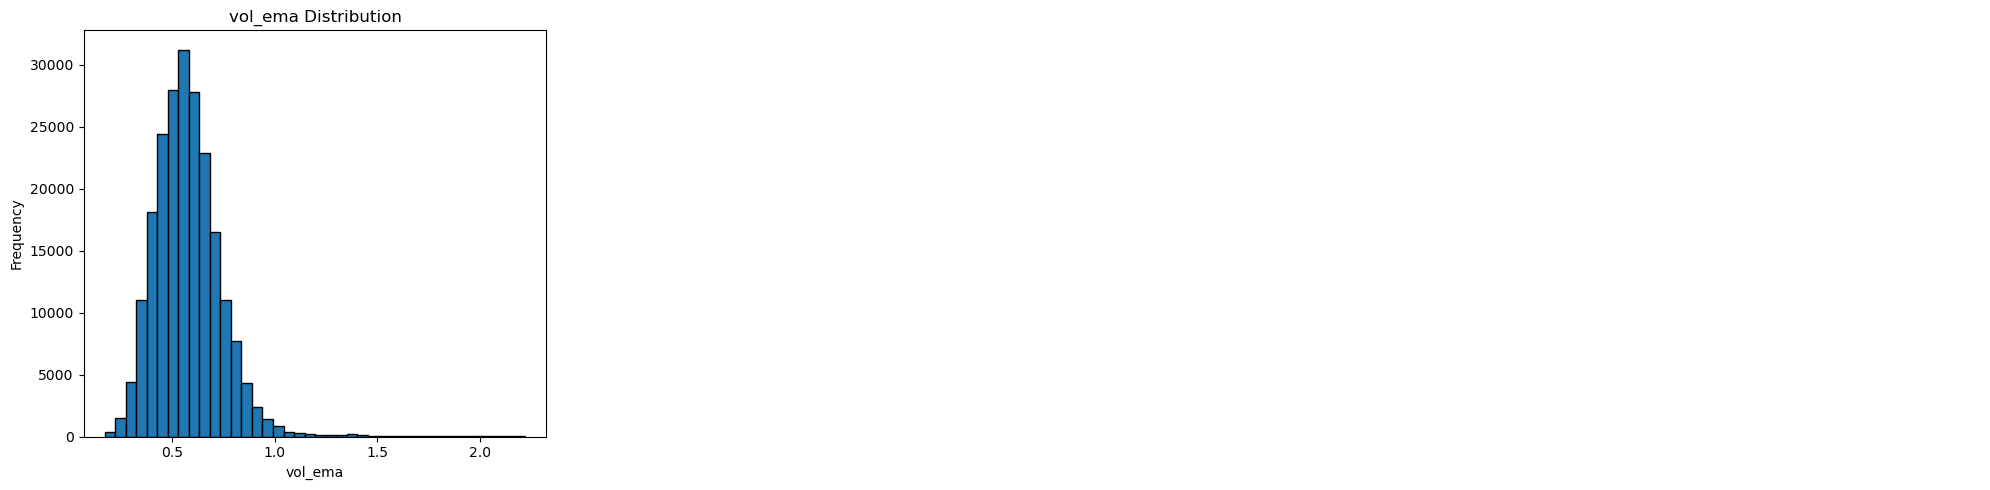

In [49]:
hyper_params_btc.data_span_days = 5
hyper_params_btc.winsorize_features = ['vwap_sqmacd_over_fast_volume', 'vwap_sqmacd_over_slow_volume']
grouped_df_sample = resample_trades_data(binance_perp_btc_sample, hyper_params_btc)
filtered_df_sample = filter_trades_get_vol(grouped_df_sample, hyper_params_btc)
ema_features_df_sample = get_ema_feature(filtered_df_sample, hyper_params_btc)

hyper_params_btc.data_span_days = 1.5
hyper_params_btc.winsorize_features = []
grouped_df = resample_trades_data(binance_perp_btc, hyper_params_btc)
filtered_df = filter_trades_get_vol(grouped_df, hyper_params_btc)
ema_features_df = get_ema_feature(filtered_df, hyper_params_btc)

dist_plot(filtered_df.filter(pl.col('vol_ema') <= 10), ['vol_ema'])

In [133]:
hyper_params_btc.trade_volume_thres = 1
hyper_params_btc.ic_plot_pred_windows = [5, 15, 30, 60, 300, 600, 1800, 3600, 7200, 21600, 43200]

zscore_df = get_zscore_feature(ema_features_df, ema_features_df_sample, hyper_params_btc)
target_df = ob_stv_2(filtered_df, zscore_df, hyper_params_btc)
ic_plot_over_different_windows(target_df, hyper_params_btc)

dropped 116436 invalid data samples from 214253 samples


KeyError: 'feature'

                                  OLS Regression Results                                  
Dep. Variable:     target_return_normalized_1800s   R-squared:                       0.010
Model:                                        OLS   Adj. R-squared:                  0.009
Method:                             Least Squares   F-statistic:                     96.27
Date:                            Wed, 14 May 2025   Prob (F-statistic):          3.46e-160
Time:                                    10:32:24   Log-Likelihood:            -4.4851e+05
No. Observations:                           79791   AIC:                         8.970e+05
Df Residuals:                               79782   BIC:                         8.971e+05
Df Model:                                       8                                         
Covariance Type:                        nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      

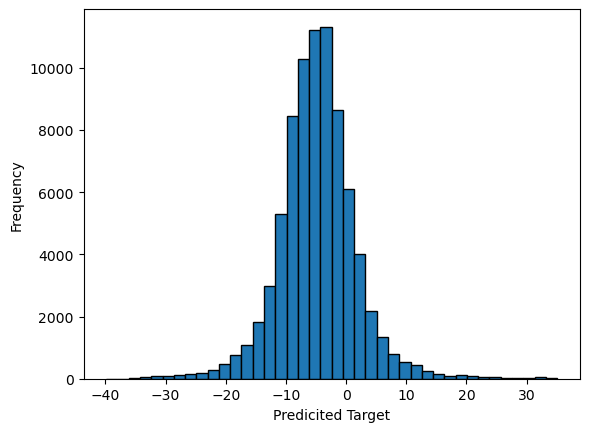

In [63]:
hyper_params_btc.ridge_alpha = 0.0
hyper_params_btc.holding_period = 3600
lr_df = linreg(target_df, hyper_params_btc)

dropped 116436 invalid data samples from 214253 samples


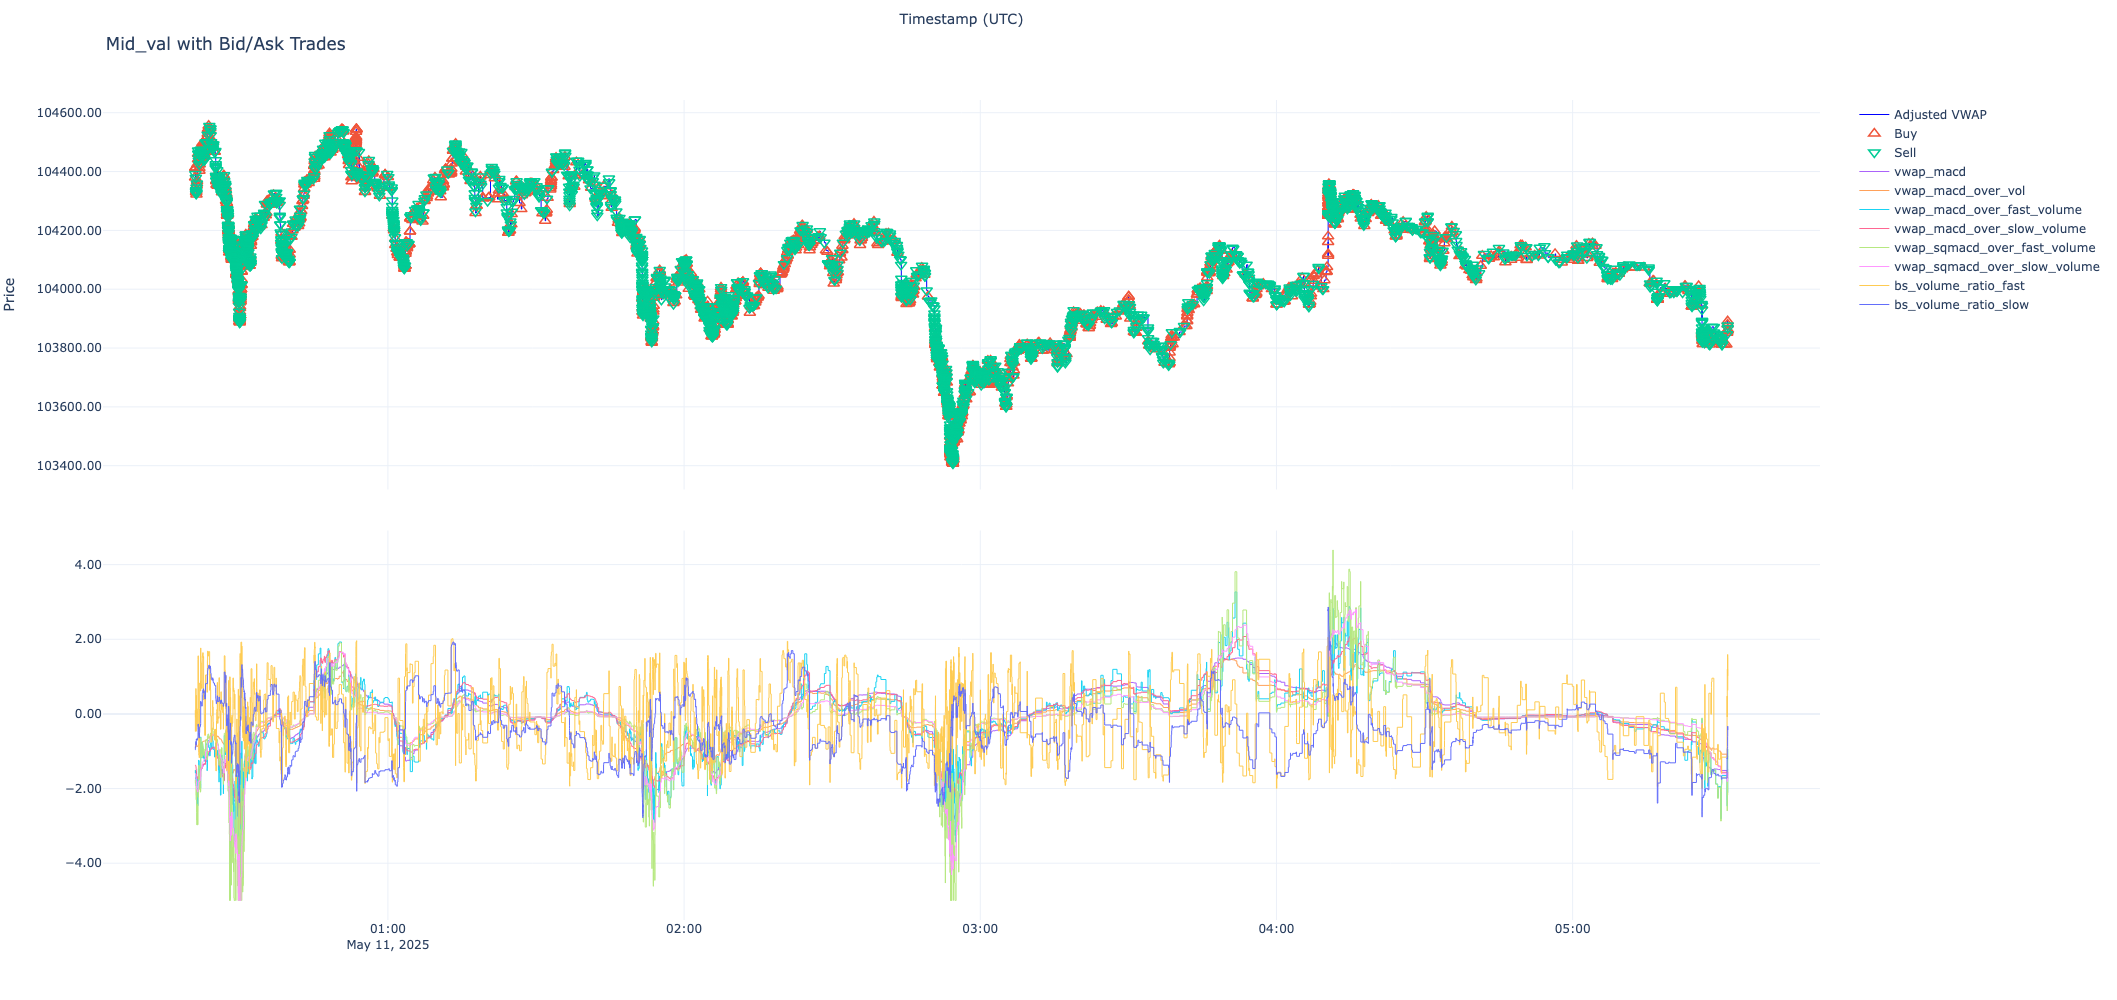

In [128]:
hyper_params_btc.trade_volume_thres = 1

target_df = ob_stv_2(filtered_df, zscore_df, hyper_params_btc)[:5000]

plot_sample_points(target_df, hyper_params_btc, mid_val_tolerance=0.5)

In [65]:
lr_df.to_pandas().corr()

,vwap_macd,vwap_macd_over_vol,vwap_macd_over_fast_volume,vwap_macd_over_slow_volume,vwap_sqmacd_over_fast_volume,vwap_sqmacd_over_slow_volume,bs_volume_ratio_fast,bs_volume_ratio_slow,target_return_normalized_1800s
vwap_macd,1.000000,0.957938,0.900428,0.951467,0.891513,0.948987,0.116156,0.423416,-0.037670
vwap_macd_over_vol,0.957938,1.000000,0.896494,0.953579,0.867987,0.930611,0.113549,0.407492,-0.019212
vwap_macd_over_fast_volume,0.900428,0.896494,1.000000,0.941108,0.946882,0.899870,0.053975,0.340449,-0.030479
vwap_macd_over_slow_volume,0.951467,0.953579,0.941108,1.000000,0.880121,0.941476,0.097828,0.372290,-0.020530
vwap_sqmacd_over_fast_volume,0.891513,0.867987,0.946882,0.880121,1.000000,0.943504,0.048375,0.338530,-0.024677
vwap_sqmacd_over_slow_volume,0.948987,0.930611,0.899870,0.941476,0.943504,1.000000,0.091367,0.371808,-0.014865
bs_volume_ratio_fast,0.116156,0.113549,0.053975,0.097828,0.048375,0.091367,1.000000,0.603028,0.010985
bs_volume_ratio_slow,0.423416,0.407492,0.340449,0.372290,0.338530,0.371808,0.603028,1.000000,0.000432
target_return_normalized_1800s,-0.037670,-0.019212,-0.030479,-0.020530,-0.024677,-0.014865,0.010985,0.000432,1.000000


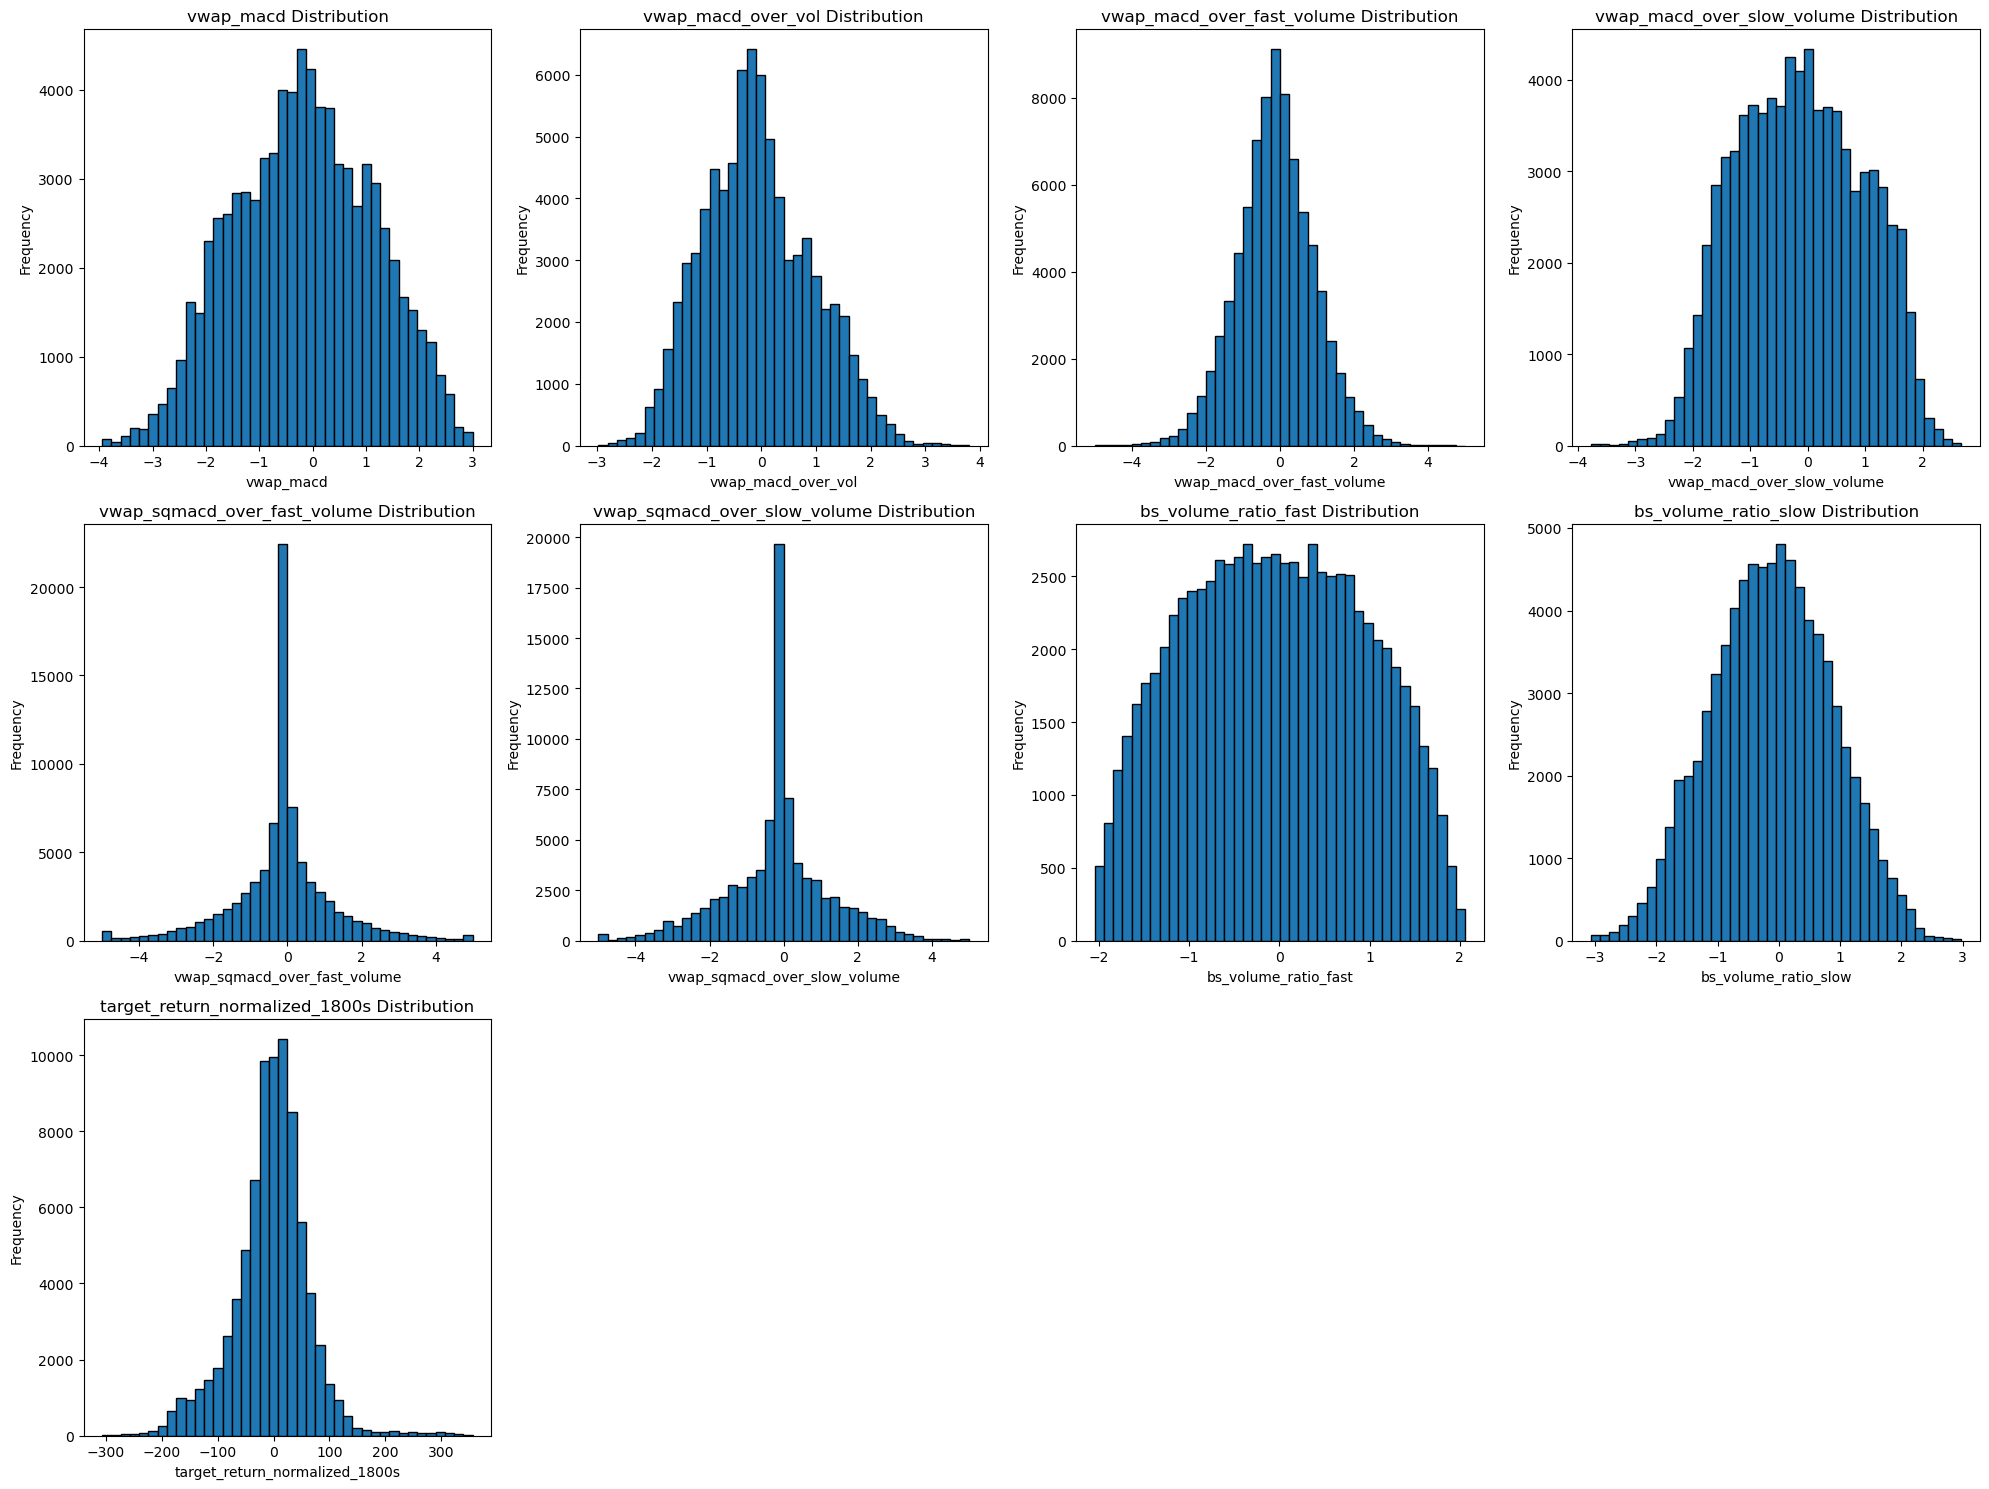

In [67]:
features_plot = lr_df.columns

dist_plot(lr_df, features_plot)

### Garbage Collection

#### Temp code for getting the vol multiplier

In [1164]:
hyper_params_memefi = DataProcessParas(
    # Step 2: Group trades and get the single trade feature we need, depends on the exchanges
    price_round = 10,
    volume_round = 10,
    latency_gap = 5_000,
    data_span_days = 1.5,
    vol_window = 100,
    
    # Step 4: Calculate aggregation features
    winsorize_features = ['vwap_macd_over_fast_volume', 'vwap_macd_over_slow_volume', 'vwap_sqmacd_over_fast_volume', 'vwap_sqmacd_over_slow_volume'],
    winsorize_qtl = 0.99,
    
    # Step 4 改: Calculate EMA Features
    vol_ema_alpha = 0.05,
    fast_ema_alpha = 0.01, 
    slow_ema_alpha = 0.001,
    zscore_threshold = 5,
    fast_decaying_sum_alpha = 0.9,
    slow_decaying_sum_alpha = 0.99,
    
    
    # Step 5: Observation Sampling and Set Target Variable
    feature_blind_spot_us = 25_000,
    env_latency_thres = 100_000,
    
    # Step 5 改: Easier way of Sampling and Set Target Variable
    trade_volume_thres = 1,
    
    env_bs_volume_ratio_thres = 3,
    env_macd_thres = 3,
    env_vol_thres = 3,
        
    # Step 6: Linear Regression
    target = 'target_return_bps',
    lr_features = ['vwap_macd', 'vwap_macd_over_vol',
                   'vwap_macd_over_fast_volume', 'vwap_macd_over_slow_volume',
                   'vwap_sqmacd_over_fast_volume', 'vwap_sqmacd_over_slow_volume',
                   'bs_volume_ratio_fast', 'bs_volume_ratio_slow'],
)

hyper_params_btc.data_span_days = 1.5
hyper_params_btc.winsorize_features = []
grouped_df = resample_trades_data(pnut_data, hyper_params_memefi)
filtered_df = filter_trades_get_vol(grouped_df, hyper_params_memefi)

dist_plot(filtered_df.filter(pl.col('vol_ema') <= 10), ['vol_ema'])

#### Local Pivot Feature Related

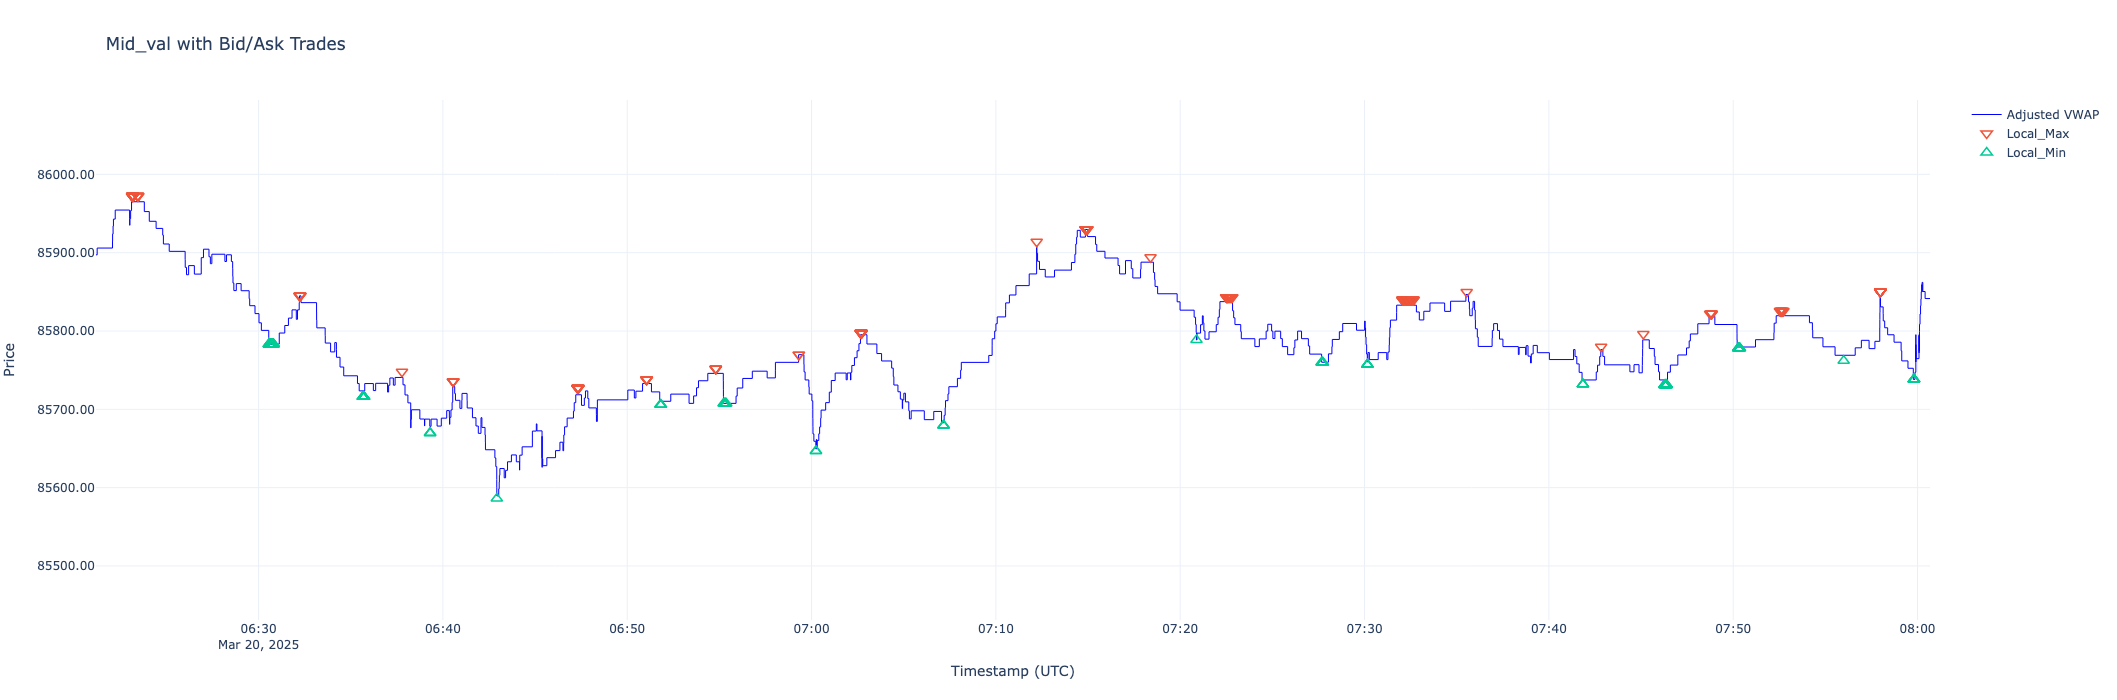

In [823]:
looking_back_us = -120_000_000 #100 seconds range checking

local_vwap_df = filtered_df.rolling(index_column="end_exch_time", offset=f'{looking_back_us}i', period=f'{-2 * looking_back_us}i').agg(
    pl.min('vwap').alias('local_min_vwap'),
    pl.max('vwap').alias('local_max_vwap'),
)

local_vwap_df = filtered_df.join(local_vwap_df, on='end_exch_time', how='left')


vwap_series = adjust_mid_val(local_vwap_df['vwap'], tolerance=1)

local_vwap_df = local_vwap_df.with_columns(
    pl.when(pl.col('vwap') == pl.col('local_min_vwap'))
    .then(pl.lit(-1))
    .when(pl.col('vwap') == pl.col('local_max_vwap'))
    .then(pl.lit(1))
    .otherwise(pl.lit(0)).alias('local_min_max'),
    vwap_series.alias('adjust_vwap')
)



def adjust_mid_val(mid_vals: pl.Series, tolerance: float) -> pl.Series:
        '''
        This is a closure function. Only update mid_val when the difference reached the min_update_bps
        
        PARAMS:
          tolerance: minimum price change for mid_val updating
          mid_vals: raw mid_val timeseries

        RETURN: adjusted mid_val timeseries
        '''
        adjusted_vals = []
        last_value = mid_vals[0]
        adjusted_vals.append(last_value)
        test = 1

        for val in mid_vals[1:]:
            test += val
            if abs((val - last_value)/last_value) >= tolerance/10000:  # Check if the value increased by 'tolerance' bps
                last_value = val
            adjusted_vals.append(last_value)
            
        print(test)

        return pl.Series(adjusted_vals)
    



def plot_trades(df: pl.DataFrame):
        '''
        fill_ratio_thresh: filter those partial filled trades
        rebates: considering rebates in trades plot
        '''
        # Convert timestamps to UTC for both datasets
        mid_val_df = df.to_pandas()
        # Convert timestamps to UTC for both datasets
        mid_val_df['timestamp_utc'] = pd.to_datetime(mid_val_df['end_exch_time'], unit='us')
        
        local_max = mid_val_df[mid_val_df['local_min_max'] == 1]
        local_min = mid_val_df[mid_val_df['local_min_max'] == -1]
        
        mid_val_df = df.filter(
            pl.col('adjust_vwap') != pl.col('adjust_vwap').shift(1).fill_null(0)
        ).to_pandas()
        # Convert timestamps to UTC for both datasets
        mid_val_df['timestamp_utc'] = pd.to_datetime(mid_val_df['end_exch_time'], unit='us')

        
        # Create step plot for adjusted_mid_val
        fig = go.Figure()

        # Make the mid_val line thinner by setting width
        fig.add_trace(go.Scatter(
            x=mid_val_df['timestamp_utc'],
            y=mid_val_df['adjust_vwap'],
            mode='lines',
            line_shape='hv',
            name='Adjusted VWAP',
            line=dict(color='blue', width=1),  # Set width for the mid_val line
        ))

        # Plot ask trades as red downward triangles (transparent fill, green edge)
        fig.add_trace(go.Scatter(
            x=local_max['timestamp_utc'],
            y=local_max['vwap'],
            mode='markers',
            marker=dict(symbol='triangle-down-open', size=10, line=dict(color='#750109', width=1.5)), 
            name='Local_Max'
        ))

        # Plot bid trades as green upward triangles (transparent fill, red edge)
        fig.add_trace(go.Scatter(
            x=local_min['timestamp_utc'],
            y=local_min['vwap'],
            mode='markers',
            marker=dict(symbol='triangle-up-open', size=10, line=dict(color='#025e36', width=1.5)),
            name='Local_Min'
        ))

        # Update layout
        fig.update_layout(
            title='Mid_val with Bid/Ask Trades',
            xaxis_title='Timestamp (UTC)',
            yaxis_title='Price',
            hovermode='closest',
            template="plotly_white",
            width=2000,  # Set the total width of the plot
            height=700,
        )

        # Update y-axis to show precise number formatting
        fig.update_yaxes(tickformat='.2f')  # Format y-axis ticks to show two decimal places

        # Show interactive plot
        fig.show()
        
    
    
plot_trades(local_vwap_df)

#### Obsearvation filtering and Target Varible engineering

In [1091]:
def ob_stv(grouped_df: pl.DataFrame, hyper_params: DataProcessParas) -> pl.DataFrame:
    '''
    Step 1: Filtering the samples that we care (where we more likely to trade)
    
    Step 2: Set a apropriate target variable - vwap diff between current significant trade and next opposite significant trade 
    
    Step 3: Normalize the target variable with rolling vwap std (which is also required by production)
    
    Step 4: Filter out high latency data points
    '''
    # Access to hyperparamters
    beta_vol = hyper_params.beta_vol
    fixed_spread = hyper_params.fixed_spread
    target_blind_spot_us = hyper_params.target_blind_spot_us
    latency_thres = hyper_params.latency_thres
    offset = hyper_params.offset
    
    # Step 1: Valid vwap diff should meet such condition: last trade should be the most recent one happened at least {target_blind_spot} ms before
    target_df = grouped_df.with_columns(
        pl.last("vwap").rolling(index_column="end_exch_time", offset=f'{offset}i', period=f'{-target_blind_spot_us-offset}i').alias(f'rolling_{int(target_blind_spot_us/1000)}ms_vwap')
    ).drop_nulls().with_columns(
        ((pl.col('vwap') - pl.col(f'rolling_{int(target_blind_spot_us/1000)}ms_vwap')) / pl.col('vwap') * 10_000).alias('valid_vwap_diff')
    )
    
    # It's more accurate to calculate the valid vwap diff before volume filtering!
    target_df = filter_trades_get_vol(target_df, hyper_params)
    
    # Step 2.1: Calculate the spread we will set in production, to filter the significant trade we most care about
    target_df = target_df.with_columns(
        (pl.col("vol_ema") * beta_vol + fixed_spread).alias('prod_spread')
    ).filter(
        ((pl.col('valid_vwap_diff') >= pl.col('prod_spread')) & (pl.col('side') == 'buy')) | ((pl.col('valid_vwap_diff') <= -pl.col('prod_spread')) & (pl.col('side') == 'sell')),
    )
            
    # Step 2.2: Calculate the target varible: current_vawp - next_opposite_trade_vwap
    target_df = target_df.with_columns(
        (pl.when(pl.col('side') == 'sell').then(pl.lit(0)).otherwise(pl.lit(1)).diff().abs().cum_sum().fill_null(0)).alias('target_bucket_id')
    )
    
    # Step 2.3: Get the next opposite trade vwap
    target_df_2 = target_df.select(
        (pl.col('target_bucket_id') - 1).alias('target_bucket_id'),
        pl.col('vwap').alias('vwap')
    ).group_by('target_bucket_id').agg(
        pl.col('vwap').first().alias('next_trade_price')
    )
    
    # Step 2.4: Merge it back to original df, then we can get our target variable
    target_df = target_df.join(target_df_2, on='target_bucket_id', how='left').drop_nulls().with_columns(
        ((pl.col('next_trade_price') - pl.col('vwap')) / pl.col('vwap') * 10000).alias('target_return_bps')
    )
    
    # Step 3: Normalize target variable with rolling vwap std
    target_df = target_df.with_columns(
        (pl.col('target_return_bps') / pl.col('vol_ema')).alias('target_return_normalized')
    )
    
    # Step 4: Final filter - filter out repetition samples which are too close to each other and high latency samples
    target_df = target_df.filter(
        pl.col('end_exch_time').diff() >= target_blind_spot_us,
        pl.col('recv_latency') <= latency_thres
    )
    
    return target_df

#### Step 4: Calculate aggregation features and rolling z-score

In [ ]:
def agg_feature(filtered_df: pl.DataFrame, hyper_params: DataProcessParas, feature_window: int) -> pl.DataFrame:
    '''
    Calculate the aggregation features and drop outliers via winsorize
    
    Features: "vwap_diff_sum", "buy_count_ratio", "vwap"
    
    Features that need to be winsorized: ""
    '''
    # Access to hyperparamters
    winsorize_features = hyper_params.winsorize_features
    winsorize_qtl = hyper_params.winsorize_qtl
    feature_blind_spot_us = hyper_params.feature_blind_spot_us
    offset = hyper_params.offset
    lr_features = hyper_params.lr_features + ['bucket_id']
        
    # Calculate the agg features using the datapoint that are out of blind spot period (index_column="index", offset=f"{-feature_window}i", period=f"{feature_window}i")'
    # Use end_exch_time is more strictly, means we couldn't use the information within the same large trade. (which kind make sense as well)
    agg_feature_df = filtered_df.with_row_index().rolling(index_column="end_exch_time", offset=f'{offset}i', period=f'{-feature_blind_spot_us-offset}i').agg(
        pl.len().alias("sample_num"),
        
        # vwap related
        pl.col('vwap').tail(feature_window).last().alias('current_px'),
        pl.col('vwap').tail(feature_window).first().alias('initial_px'),
        ((pl.col("vwap") * pl.col("volume")).sum() / pl.col("volume").sum()).alias("agg_vwap"),
        
        # volume related
        pl.col('volume').tail(feature_window).sum().alias('volume'),
        pl.col('volume').tail(feature_window).filter(pl.col('side').tail(feature_window) == 'buy').sum().alias('buy_volume'),
        pl.col('volume').tail(feature_window).filter(pl.col('side').tail(feature_window) == 'sell').sum().alias('sell_volume'),
        
        # misc
        pl.col('vwap_slippage').tail(feature_window).filter(pl.col('side').tail(feature_window) == 'buy').sum().alias('buy_slippage'),
        pl.col('vwap_slippage').tail(feature_window).filter(pl.col('side').tail(feature_window) == 'sell').sum().alias('sell_slippage'),
        
    ).with_columns(
        # Attach the bucket_id back
        filtered_df['bucket_id'].alias('bucket_id'),
        
        # Complex agg features that rely on previous basic agg features
        (((pl.col('first_vwap') - pl.col('vwap')).pow(2))/ pl.col('volume')).alias('book_impact'),
    )
    
    # Drop data which has less data points than feature window (mostly at warm-up period)
    agg_feature_df = agg_feature_df.filter(pl.col('sample_num') >= feature_window)
    
    # Drop outliers via winsorize over entire sample
    for feature in winsorize_features:
        up_limit = agg_feature_df[feature].quantile(winsorize_qtl)
        agg_feature_df = agg_feature_df.with_columns(
            pl.when(pl.col(feature) >= up_limit).then(up_limit).otherwise(pl.col(feature)).alias(feature),
        )
    
    return agg_feature_df.select(lr_features)

In [ ]:
# Rolling z-score or rolling rv is hard to calibrate, thus leaving it for now

def rolling_zscore(agg_df: pl.DataFrame, zscore_window: int) -> pl.DataFrame:
    '''
    Calculate the rolling z-score of features.
    
    Default: All features will be replaced by their rolling z-score
    '''
    zscore_df = agg_df.with_row_index().rolling(index_column="index", period=f"{zscore_window}i").agg(
        pl.col('bucket_id').last(),
        *[((pl.col(col).last() - pl.col(col).mean()) / pl.col(col).std()).alias(col) for col in agg_df.columns if col != "bucket_id"]
    )
    
    # Drop data in the warm-up period
    zscore_df = zscore_df[zscore_window:]
    
    return zscore_df

def rolling_rv(agg_df: pl.DataFrame, ema_alpha: int=0.02) -> pl.DataFrame:
    '''
    Calculate the rolling val/ema(val)
    
    Default: All features will be replaced by their rolling z-score
    '''
    min_samples = 100
    rv_df = agg_df.select(
        pl.col('bucket_id'),
        *[(pl.col(col) / pl.col(col).ewm_mean(alpha=ema_alpha, adjust=False)).alias(col) for col in agg_df.columns if col != "bucket_id"]
    )
    
    # Drop data in the warm-up period
    rv_df = rv_df[min_samples:]
    
    return rv_df